# Receptor modeling - scraps

In [1]:
var('a12, a21, a13, a31, a23, a32, a34, a43')
d = {1: {2:a12, 3:a13}, 2: {1:a21, 3:a23}, 3: {2:a32, 1:a31, 4:a34}, 4: {3:a43}};
G = DiGraph(d,weighted=True)
G.plot(figsize=8,edge_labels=True,pos=vertex_positions,graph_border=True)

NameError: name 'vertex_positions' is not defined

The weighted adjacency matrix for `G` is

In [2]:
A = G.weighted_adjacency_matrix()
A

[  0 a12 a13   0]
[a21   0 a23   0]
[a31 a32   0 a34]
[  0   0 a43   0]

The Laplacian of `G` is:

In [3]:
L = G.laplacian_matrix()
L

[      a21 + a31            -a12            -a13               0]
[           -a21       a12 + a32            -a23               0]
[           -a31            -a32 a13 + a23 + a43            -a34]
[              0               0            -a43             a34]

This matrix is sometimes referred to as the `combinatorial Laplacian matrix` of the weighted directed graph `G`.


## Generator matrix and Laplacian 

The generator matrix `Q` for the Markov chain associated to `G` can be constructed from the weighted adjacency matrix `A` as folows.

In [4]:
Q = A - diagonal_matrix(sum(A.T))

The following code defines `e` to be column vector of ones.  This is used to show that each row of `Q` sums to zero.

In [5]:
e = matrix([1,1,1,1]).T

In [6]:
print(Q*e)

[0]
[0]
[0]
[0]


Multiplying on the left by the transpose of `e`, given by `e.T`, we see that each column of `Q` does not sum to zero.

In [7]:
print(e.T*Q)

[           -a12 - a13 + a21 + a31             a12 - a21 - a23 + a32 a13 + a23 - a31 - a32 - a34 + a43                         a34 - a43]


## Three state model


As a simple example, consider a receptor model with three states arranged as follows.

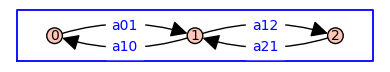

In [8]:
G = DiGraph({0: {1:'a01'}, 1: {0:'a10', 2:'a12'}, 2: {1:'a21'}})
pos = {0: (0, 0), 1: (1, 0), 2: (2, 0)}
G.plot(figsize=4,edge_labels=True,pos=pos,graph_border=True)

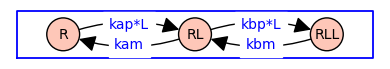

In [9]:
G = DiGraph({'R': {'RL':'kap*L'}, 'RL': {'R':'kam', 'RLL':'kbp*L'}, 'RLL': {'RL':'kbm'}})
pos = {'R': (0, 0), 'RL': (1, 0), 'RLL': (2, 0)}
G.plot(figsize=4,edge_labels=True,pos=pos,graph_border=True,vertex_size=1000)

When both forward and reverse transitions are explicit, the state-transition diagram has the topology of a symmetric directed version of the [path graph](example_graphs:path_graph) with 3 vertices.

Here is the (undirected) path graph {math}`P_3`:

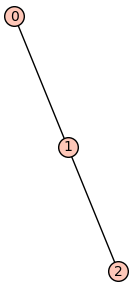

In [10]:
G = Graph({0: [1], 1: [2]})
G.plot(figsize=4)

The symmetric directed version is

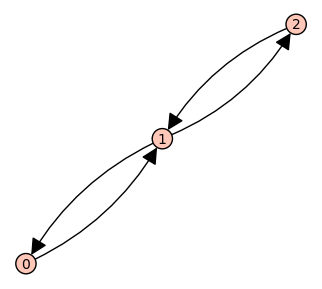

In [11]:
G = DiGraph({0: [1], 1: [0,2], 2: [1]})
G.plot(figsize=4)